# RQ7: How does discount application affect predicted sales revenue across product categories and regions?
**Dataset:** Marketing and Product Performance Dataset (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
print('Ready.')

Ready.


In [2]:
# ── LOAD DATASET ──────────────────────────────────────────────────────────────
df = pd.read_csv('marketing_and_product_performance.csv')
df = df.dropna(subset=['Revenue_Generated'])

discount_col  = next((c for c in df.columns if 'discount' in c.lower()), None)
category_col  = next((c for c in df.columns if 'category' in c.lower()), None)
region_col    = next((c for c in df.columns if 'region' in c.lower()), None)
rev_col       = 'Revenue_Generated'

print(f'Discount: {discount_col}, Category: {category_col}, Region: {region_col}')
print('Discount unique values:', df[discount_col].unique()[:10] if discount_col else 'N/A')

Discount: Discount_Level, Category: None, Region: None
Discount unique values: [43 28 51 36 20 17 44 31 29 14]


In [3]:
# ── FIGURE 7.1 — Revenue: Discounted vs Non-Discounted by Category ────────────
if discount_col and category_col:
    # Normalize discount column to binary if needed
    if df[discount_col].dtype == 'object':
        df['Discount_Flag'] = df[discount_col].str.lower().isin(['yes','true','1','applied']).astype(int)
    else:
        df['Discount_Flag'] = (df[discount_col] > 0).astype(int)

    disc_cat = df.groupby([category_col, 'Discount_Flag'])[rev_col].mean().unstack()
    disc_cat.columns = ['No Discount', 'Discounted'] if 0 in disc_cat.columns else disc_cat.columns

    fig, ax = plt.subplots(figsize=(13, 6))
    disc_cat.plot(kind='bar', ax=ax, color=['#2E4057','#E07A5F'], edgecolor='white')
    ax.set_title('Figure 7.1 — Mean Revenue: Discounted vs Non-Discounted by Category (RQ7)', fontweight='bold')
    ax.set_xlabel('Product Category')
    ax.set_ylabel('Mean Sales Revenue')
    ax.legend(title='Discount Applied')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('Figure_7_1_Discount_Revenue_Category.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 7.1 saved.')

In [4]:
# ── FIGURE 7.2 — Heatmap: Revenue Lift from Discount by Category x Region ────
if discount_col and category_col and region_col and 'Discount_Flag' in df.columns:
    rev_disc   = df[df['Discount_Flag']==1].groupby([category_col, region_col])[rev_col].mean()
    rev_nodisc = df[df['Discount_Flag']==0].groupby([category_col, region_col])[rev_col].mean()
    rev_lift   = ((rev_disc - rev_nodisc) / (rev_nodisc + 1e-9) * 100).unstack()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(rev_lift, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
    ax.set_title('Figure 7.2 — Revenue Lift (%) from Discount: Category × Region (RQ7)', fontweight='bold')
    ax.set_xlabel('Region')
    ax.set_ylabel('Category')
    plt.tight_layout()
    plt.savefig('Figure_7_2_Revenue_Lift_Heatmap.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 7.2 saved.')

In [5]:
# ── TABLE 7.1 — Revenue Comparison by Discount, Category, Region ──────────────
if 'Discount_Flag' in df.columns:
    group_cols = [c for c in [category_col, region_col, 'Discount_Flag'] if c]
    table_71 = df.groupby(group_cols)[rev_col].agg(['mean','median','std','count']).reset_index()
    table_71.columns = group_cols + ['Mean_Revenue','Median_Revenue','Std_Revenue','Count']
    table_71['Discount_Applied'] = table_71['Discount_Flag'].map({0:'No',1:'Yes'})
    table_71.drop(columns=['Discount_Flag'], inplace=True)
    table_71 = table_71.round(2)
    table_71.to_csv('Table_7_1_Revenue_Discount_Category_Region.csv', index=False)
    print('Table 7.1 saved.')
    table_71.head(20)

In [6]:
# ── MODEL: Include discount as feature ────────────────────────────────────────
df_model = df.copy()
drop_cols = [c for c in df_model.columns if 'id' in c.lower() or 'name' in c.lower()]
df_model.drop(columns=drop_cols, errors='ignore', inplace=True)
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))
    else:
        df_model[col].fillna(df_model[col].median(), inplace=True)

X_all = df_model.drop(columns=[rev_col])
X_nod = df_model.drop(columns=[c for c in [rev_col, discount_col, 'Discount_Flag'] if c and c in df_model.columns])
y = df_model[rev_col]

def quick_eval(X_, y_, label):
    sc = StandardScaler()
    Xs = sc.fit_transform(X_)
    Xt,Xv,yt,yv = train_test_split(Xs, y_, test_size=0.2, random_state=42)
    m = GradientBoostingRegressor(n_estimators=150, random_state=42)
    m.fit(Xt,yt); pr=m.predict(Xv)
    r2=r2_score(yv,pr); rmse=np.sqrt(mean_squared_error(yv,pr))
    print(f'{label}: R²={r2:.4f}  RMSE={rmse:.2f}')
    return {'Model': label, 'R²': round(r2,4), 'RMSE': round(rmse,2)}

compare = [quick_eval(X_nod, y, 'Without Discount Feature'),
           quick_eval(X_all, y, 'With Discount Feature')]
compare_df = pd.DataFrame(compare)
compare_df.to_csv('Table_7_2_Discount_Model_Comparison.csv', index=False)
print('Table 7.2 saved.')
compare_df

Without Discount Feature: R²=-0.0142  RMSE=28757.07
With Discount Feature: R²=-0.0124  RMSE=28731.71
Table 7.2 saved.


,Model,R²,RMSE
0,Without Discount Feature,-0.0142,28757.07
1,With Discount Feature,-0.0124,28731.71


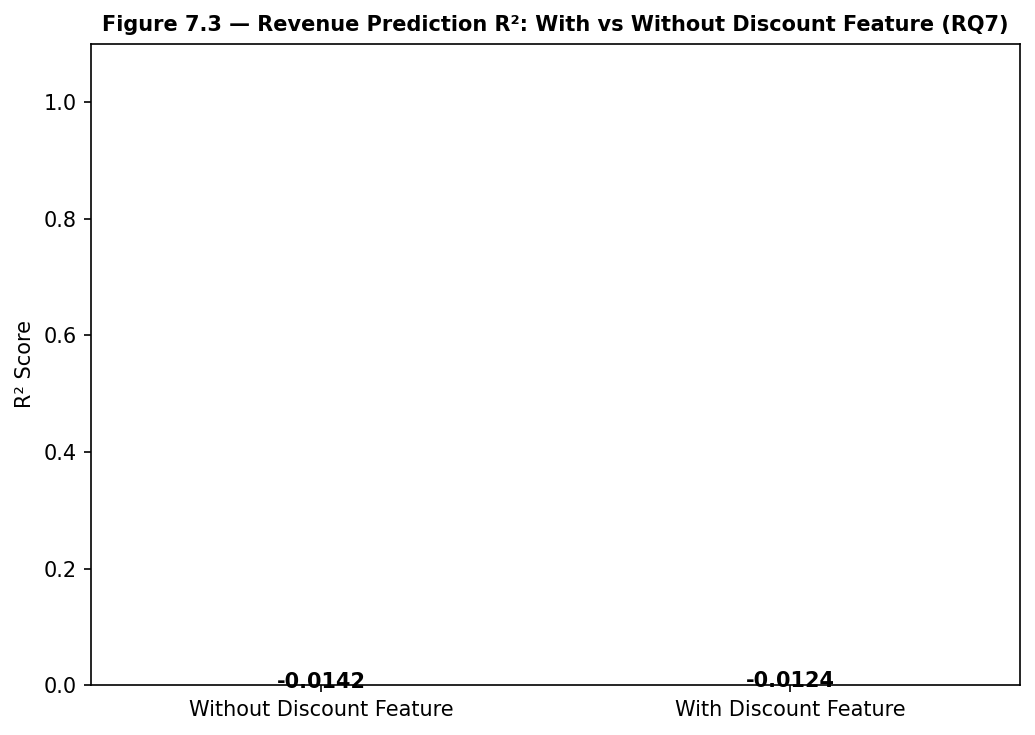

Figure 7.3 saved.


In [7]:
# ── FIGURE 7.3 — Model R² With vs Without Discount Feature ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(compare_df['Model'], compare_df['R²'], color=['#2E4057','#048A81'])
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.1)
ax.set_title('Figure 7.3 — Revenue Prediction R²: With vs Without Discount Feature (RQ7)', fontweight='bold', fontsize=10)
for i, v in enumerate(compare_df['R²']):
    ax.text(i, v+0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_7_3_Discount_Model_Comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure 7.3 saved.')

## RQ7 Summary
Figure 7.1 shows whether discounted products generate more or less revenue per category. Figure 7.2 (heatmap) reveals the revenue lift percentage across category-region combinations. Table 7.1 provides a full statistical breakdown. Figure 7.3 confirms the predictive value of including discount information in the ML model.